# Word2Vec Implementation from Scratch,
    
  This notebook implements a simple Word2Vec model using the Skip-gram architecture.
  

## 1. Data Preparation

In [115]:
text = '''
In the kingdom, King Edward and Queen Sophia ruled with kindness and 
wisdom. Their children, Prince Henry and Princesses Emma and Isabella, 
were the light of their parents' eyes. The royal family was loved by 
all, and their kingdom prospered under their gentle rule. Prince Henry 
was brave and adventurous, while Princess Emma was gentle and 
compassionate. Princess Isabella was clever and curious, always 
seeking knowledge and wisdom. Together, the royal family brought 
peace and happiness to their kingdom.
'''


## 2. Text Tokenization

Convert all the words to lowercase

In [116]:
import re

def tokenize(text):
    pattern = re.compile(r'[A-Za-z]+[\w^\']*|[\w^\']*[A-Za-z]+[\w^\']*')
    return pattern.findall(text.lower())


In [117]:
tokens = tokenize(text)

In [118]:
tokens

['in',
 'the',
 'kingdom',
 'king',
 'edward',
 'and',
 'queen',
 'sophia',
 'ruled',
 'with',
 'kindness',
 'and',
 'wisdom',
 'their',
 'children',
 'prince',
 'henry',
 'and',
 'princesses',
 'emma',
 'and',
 'isabella',
 'were',
 'the',
 'light',
 'of',
 'their',
 "parents'",
 'eyes',
 'the',
 'royal',
 'family',
 'was',
 'loved',
 'by',
 'all',
 'and',
 'their',
 'kingdom',
 'prospered',
 'under',
 'their',
 'gentle',
 'rule',
 'prince',
 'henry',
 'was',
 'brave',
 'and',
 'adventurous',
 'while',
 'princess',
 'emma',
 'was',
 'gentle',
 'and',
 'compassionate',
 'princess',
 'isabella',
 'was',
 'clever',
 'and',
 'curious',
 'always',
 'seeking',
 'knowledge',
 'and',
 'wisdom',
 'together',
 'the',
 'royal',
 'family',
 'brought',
 'peace',
 'and',
 'happiness',
 'to',
 'their',
 'kingdom']

In [119]:
# Total number of tokens
len(tokens)

79

In [120]:

# Total number of unique tokens
len(set(tokens))

49

In [121]:
set(tokens)

{'adventurous',
 'all',
 'always',
 'and',
 'brave',
 'brought',
 'by',
 'children',
 'clever',
 'compassionate',
 'curious',
 'edward',
 'emma',
 'eyes',
 'family',
 'gentle',
 'happiness',
 'henry',
 'in',
 'isabella',
 'kindness',
 'king',
 'kingdom',
 'knowledge',
 'light',
 'loved',
 'of',
 "parents'",
 'peace',
 'prince',
 'princess',
 'princesses',
 'prospered',
 'queen',
 'royal',
 'rule',
 'ruled',
 'seeking',
 'sophia',
 'the',
 'their',
 'to',
 'together',
 'under',
 'was',
 'were',
 'while',
 'wisdom',
 'with'}

## 3. Word-to-ID Mapping

Create a mapping of words to their corresponding IDs and vice versa.

In [122]:
def mapping(tokens):
    word_to_id = {}
    id_to_word = {}
    
    for i, token in enumerate(set(tokens)):
        word_to_id[token] = i
        id_to_word[i] = token
    
    return word_to_id, id_to_word


In [123]:
word_to_id, id_to_word = mapping(tokens)
word_to_id


{'all': 0,
 'light': 1,
 'was': 2,
 'under': 3,
 'king': 4,
 'the': 5,
 'peace': 6,
 'while': 7,
 'brave': 8,
 'wisdom': 9,
 'gentle': 10,
 'sophia': 11,
 'were': 12,
 'kingdom': 13,
 'seeking': 14,
 'children': 15,
 'happiness': 16,
 'henry': 17,
 'queen': 18,
 'prospered': 19,
 'always': 20,
 'brought': 21,
 'princess': 22,
 'to': 23,
 'with': 24,
 'and': 25,
 'royal': 26,
 'together': 27,
 'isabella': 28,
 'edward': 29,
 'family': 30,
 "parents'": 31,
 'adventurous': 32,
 'emma': 33,
 'clever': 34,
 'in': 35,
 'ruled': 36,
 'eyes': 37,
 'by': 38,
 'compassionate': 39,
 'curious': 40,
 'princesses': 41,
 'rule': 42,
 'prince': 43,
 'knowledge': 44,
 'kindness': 45,
 'loved': 46,
 'their': 47,
 'of': 48}

## 4. Generate Training Data

In [124]:
# Generate one-hot encoded training data for the Skip-gram model.
import numpy as np

np.random.seed(42)


def generate_training_data(tokens, word_to_id, window):
    X = []  # center word
    y = []  # context words
    n_tokens = len(tokens)
    
    for i in range(n_tokens):
        idx = concat(
            range(max(0, i - window), i), 
            range(i, min(n_tokens, i + window + 1))
        )
        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encode(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encode(word_to_id[tokens[j]], len(word_to_id)))
    
    return np.asarray(X), np.asarray(y)


In [125]:
def concat(*iterables):
    for iterable in iterables:
        yield from iterable


In [126]:
def one_hot_encode(id, vocab_size):
    res = [0] * vocab_size
    res[id] = 1
    return res


In [127]:
# Generate training data with a window size of 2
X, y = generate_training_data(tokens, word_to_id, 2)

In [128]:
X.shape # (2+3+(75*4)+3+2 = 310)


(310, 49)

In [129]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [130]:
y.shape

(310, 49)

In [131]:
y

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]])

## 5. Model Implementation

In [132]:
def init_network(vocab_size, n_embedding):
    model = {
        "w1": np.random.randn(vocab_size, n_embedding),
        "w2": np.random.randn(n_embedding, vocab_size)
    }
    return model


Initialize the model with random weights with vocab size as vocab_size and embedding size as 10.


In [133]:
model = init_network(len(word_to_id), 10)

In [134]:
def forward(model, X, return_cache=True):
    cache = {}
    
    cache["a1"] = X @ model["w1"]   # input layer to hidden layer   
    cache["a2"] = cache["a1"] @ model["w2"] # hidden layer to output layer
    cache["z"] = softmax(cache["a2"]) # softmax activation function
    
    if not return_cache:
        return cache["z"]
    return cache


In [135]:
def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res


In [136]:
(X @ model["w1"]).shape # Input layer to hidden layer

/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/2232654217.py:1: RuntimeWarning: divide by zero encountered in matmul
  (X @ model["w1"]).shape # Input layer to hidden layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/2232654217.py:1: RuntimeWarning: overflow encountered in matmul
  (X @ model["w1"]).shape # Input layer to hidden layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/2232654217.py:1: RuntimeWarning: invalid value encountered in matmul
  (X @ model["w1"]).shape # Input layer to hidden layer


(310, 10)

In [137]:
(X @ model["w1"] @ model["w2"]).shape # Hidden layer to output layer

/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/1943425430.py:1: RuntimeWarning: divide by zero encountered in matmul
  (X @ model["w1"] @ model["w2"]).shape # Hidden layer to output layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/1943425430.py:1: RuntimeWarning: overflow encountered in matmul
  (X @ model["w1"] @ model["w2"]).shape # Hidden layer to output layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/1943425430.py:1: RuntimeWarning: invalid value encountered in matmul
  (X @ model["w1"] @ model["w2"]).shape # Hidden layer to output layer


(310, 49)

## Backpropagation

In [138]:
def backward(model, X, y, alpha):
    cache  = forward(model, X)
    da2 = cache["z"] - y  # error between predicted and actual output
    dw2 = cache["a1"].T @ da2 # gradient for w2
    da1 = da2 @ model["w2"].T # error in hidden layer
    dw1 = X.T @ da1 # gradient for w1
    assert(dw2.shape == model["w2"].shape)
    assert(dw1.shape == model["w1"].shape)
    model["w1"] -= alpha * dw1 # update w1
    model["w2"] -= alpha * dw2 # update w2
    return cross_entropy(cache["z"], y) # cross entropy loss


Cross Entropy Loss
$$H(p, q) = -\sum_{x \in \chi} p(x) \log q(x)$$

In [139]:
def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)


## 6. Model Training

/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/3331993641.py:4: RuntimeWarning: divide by zero encountered in matmul
  cache["a1"] = X @ model["w1"]   # input layer to hidden layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/3331993641.py:4: RuntimeWarning: overflow encountered in matmul
  cache["a1"] = X @ model["w1"]   # input layer to hidden layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/3331993641.py:4: RuntimeWarning: invalid value encountered in matmul
  cache["a1"] = X @ model["w1"]   # input layer to hidden layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/3331993641.py:5: RuntimeWarning: divide by zero encountered in matmul
  cache["a2"] = cache["a1"] @ model["w2"] # hidden layer to output layer
/var/folders/cj/gmly58b12_56fchf3z7w4nw00000gn/T/ipykernel_65742/3331993641.py:5: RuntimeWarning: overflow encountered in matmul
  cache["a2"] = cache["a1"] @ model["w2"] # hidden layer to output layer


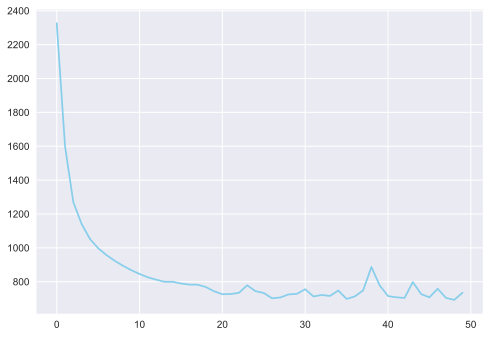

In [140]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
# Using seaborn-v0_8 style (compatible with newer matplotlib versions)
# If seaborn is not installed, you can use: "seaborn-whitegrid", "seaborn-darkgrid", or remove this line

plt.style.use("seaborn-v0_8")

n_iter = 50
learning_rate = 0.05

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]

plt.plot(range(len(history)), history, color="skyblue")
plt.show()


In [141]:
# Predicting the word for the word "king"

learning = one_hot_encode(word_to_id["king"], len(word_to_id))
result = forward(model, [learning], return_cache=False)[0]

for word in (id_to_word[id] for id in np.argsort(result)[::-1]):
    print(word)


the
and
edward
kingdom
light
royal
by
princess
their
isabella
loved
gentle
happiness
family
adventurous
king
parents'
always
in
under
prospered
brought
sophia
clever
while
henry
emma
eyes
compassionate
were
to
of
all
kindness
knowledge
curious
children
was
rule
queen
seeking
wisdom
together
ruled
prince
brave
peace
princesses
with


In [142]:
# Extracting the word embeddings
model["w1"]

array([[ 1.377214  ,  0.25468973, -1.0941617 ,  0.56022733, -0.36613477,
        -0.53641585,  0.77677647,  1.64547509,  0.55546952, -1.38553533],
       [-0.83200312,  0.40008001,  1.23311724, -0.67817793,  1.25892428,
        -0.548688  , -1.43093752,  0.24637003, -1.03590202, -0.90511178],
       [ 1.42478176,  0.50113058,  0.28865258,  0.9225778 ,  0.15042588,
        -0.80737952,  0.1241954 ,  1.02280973, -0.61725237,  0.51483367],
       [-0.12666045,  1.85765275, -1.11620898, -0.36213224,  2.05083578,
        -1.63301687, -0.95384768, -1.00580807, -0.54113097, -0.17291998],
       [ 1.94331141, -0.0498454 , -0.78436071, -0.16257478,  0.13647851,
         0.30628952, -1.63687387,  0.87986241,  1.11636694, -0.85990594],
       [-0.14657596, -0.3782881 ,  0.88647826, -1.36238777,  1.46433234,
         1.39058032, -0.83222873, -0.98408356,  0.54395385,  0.54733106],
       [ 0.09066594, -0.8602028 , -2.13255992, -1.21126228,  0.23795541,
        -0.39483056, -0.2360449 ,  1.57222826

## 7. Word Embedding Extraction

In [143]:
# Extracting the word embeddings for a given word
def get_embedding(model, word):
    try:
        idx = word_to_id[word] # get the index of the word
    except KeyError:
        print("`word` not in corpus")
    one_hot = one_hot_encode(idx, len(word_to_id)) # one hot encode the index
    return forward(model, one_hot)["a1"] # forward pass to get the embedding


In [144]:
get_embedding(model, "king")

array([ 1.94331141, -0.0498454 , -0.78436071, -0.16257478,  0.13647851,
        0.30628952, -1.63687387,  0.87986241,  1.11636694, -0.85990594])

## 8. Find similarity between words

In [145]:
# %pip install scipy

In [146]:

from scipy import spatial

# Find similarity between two words using cosine similarity
def find_similarity(word1, word2, model, word_to_id):
    embedding1 = get_embedding(model, word1)
    embedding2 = get_embedding(model, word2)
    similarity = 1 - spatial.distance.cosine(embedding1, embedding2)
    return similarity

similarity = find_similarity("prince", "brave", model, word_to_id)
print(similarity)



0.49907971580670785


In [147]:
similarity = find_similarity("princess", "rule", model, word_to_id)
print(similarity)


-0.23469197953419285


In [148]:
def find_max_similar_words(word, model, word_to_id, id_to_word, n=10):
    similarities = {}
    for w in id_to_word.values():
        if w != word:
            similarity = find_similarity(word, w, model, word_to_id)
            similarities[w] = similarity
    max_similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:n]
    return max_similar_words

max_similar_words = find_max_similar_words("prince", model, word_to_id, id_to_word)
for word, similarity in max_similar_words:
    print(f"{word}: {similarity}")



children: 0.5780774648406275
henry: 0.5508545239128814
brave: 0.49907971580670785
parents': 0.4916465328909916
their: 0.49044915964525293
gentle: 0.48886851026775335
princesses: 0.47608198230763055
royal: 0.44961965926880043
by: 0.38823606670198885
rule: 0.3744458458805996
